In [2]:
import pandas as pd
import networkx as nx

# Correct file path
file_path = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\Extracted\BIOGRID-ORGANISM-Homo_sapiens-4.4.218.tab3.txt"

# Load the interaction data
df = pd.read_csv(file_path, sep='\t', low_memory=False)

# Display the first few rows to check column names
print(df.head())


   #BioGRID Interaction ID Entrez Gene Interactor A Entrez Gene Interactor B  \
0                      103                     6416                     2318   
1                      117                    84665                       88   
2                      183                       90                     2339   
3                      278                     2624                     5371   
4                      418                     6118                     6774   

   BioGRID ID Interactor A  BioGRID ID Interactor B  \
0                   112315                   108607   
1                   124185                   106603   
2                   106605                   108625   
3                   108894                   111384   
4                   112038                   112651   

  Systematic Name Interactor A Systematic Name Interactor B  \
0                            -                            -   
1                            -                            -   

In [21]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
file_path = r"C:\Users\kdivy\OneDrive\Desktop\COMP SYS BIOLOGY\Extracted\BIOGRID-ORGANISM-Homo_sapiens-4.4.218.tab3.txt"

# Load the interaction data
df = pd.read_csv(file_path, sep='\t', usecols=["Official Symbol Interactor A", "Official Symbol Interactor B"])

# Create the graph
G = nx.from_pandas_edgelist(df, "Official Symbol Interactor A", "Official Symbol Interactor B")

# Compute degrees and identify the top 10 hub nodes
top_10_hubs = sorted(G.degree, key=lambda x: x[1], reverse=True)[:10]

# Print the top 10 hub proteins
print("Top 10 Hub Proteins by Degree:")
for protein, degree in top_10_hubs:
    print(f"{protein}: {degree}")



Top 10 Hub Proteins by Degree:
ZRANB1: 4160
PARK2: 3426
EGFR: 3070
PLEKHA4: 2971
KIAA1429: 2932
KRAS: 2891
MYC: 2817
CCNF: 2798
CUL3: 2656
TRIM25: 2497


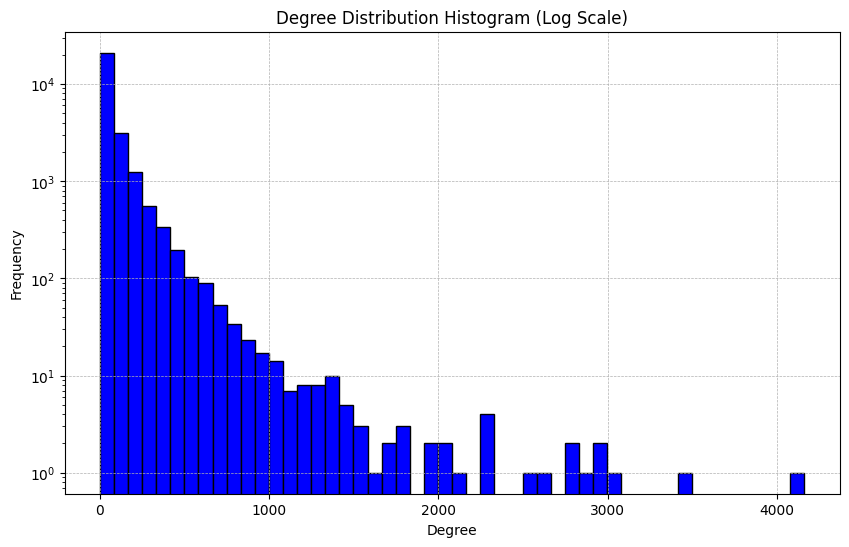

In [23]:
# Compute node degrees
degree_values = [d for _, d in G.degree()]

# Plot histogram for degree distribution
plt.figure(figsize=(10, 6))
plt.hist(degree_values, bins=50, color='blue', edgecolor='black', log=True)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution Histogram (Log Scale)")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.show()

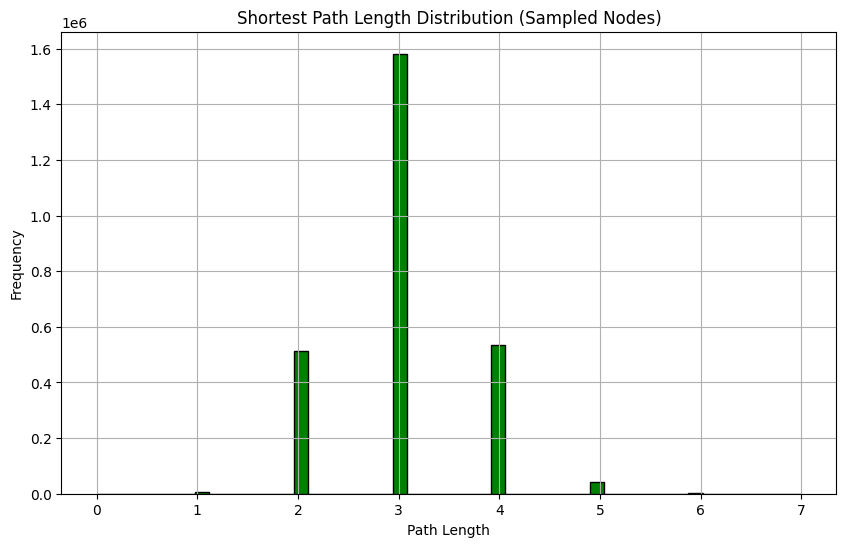

In [24]:
# Sample 100 nodes and compute shortest paths
sample_nodes = random.sample(list(G.nodes()), min(100, len(G.nodes())))
lengths = [dist for node in sample_nodes for dist in nx.single_source_shortest_path_length(G, node).values()]

# Plot histogram of shortest path lengths
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, color='green', edgecolor='black')
plt.title("Shortest Path Length Distribution (Sampled Nodes)")
plt.xlabel("Path Length")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [25]:
# Fast Centrality Computation with Sampling
sample_nodes = random.sample(list(G.nodes()), min(50, len(G.nodes())))  # Reduce to 50 nodes for speed
betweenness = nx.betweenness_centrality_subset(G, sample_nodes, sample_nodes, normalized=True)
closeness = {node: nx.closeness_centrality(G, node) for node in sample_nodes}

# Print Top 10 Nodes by Betweenness & Closeness Centrality
print("Top 10 Betweenness Centrality Nodes:", sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10])
print("\nTop 10 Closeness Centrality Nodes:", sorted(closeness.items(), key=lambda x: x[1], reverse=True)[:10])

Top 10 Betweenness Centrality Nodes: [('EGFR', 2.841219144517702e-07), ('ESR2', 1.6966331776228848e-07), ('PARK2', 1.6211047022336272e-07), ('OTUD4', 1.56951554906311e-07), ('NR3C1', 1.3919409130862165e-07), ('SPTBN1', 1.375356067308354e-07), ('TFCP2', 1.369384188110651e-07), ('NOTO', 1.3675573777187747e-07), ('SMURF1', 1.279332903332244e-07), ('VCP', 1.270265511170987e-07)]

Top 10 Closeness Centrality Nodes: [('G3BP1', 0.4438474350944815), ('PFKL', 0.4159259081276378), ('ATP6V1A', 0.41292911110386843), ('USP39', 0.40847972918907277), ('BICD2', 0.40767087075897146), ('TMED10', 0.4055335899540469), ('MED14', 0.3913952755326368), ('HIST1H2BD', 0.39015715233967807), ('ZNF609', 0.38849213749342787), ('SARNP', 0.38833994016450085)]
